# Introduction

## Project Background

Laptop merupakan salah satu perangkat penting yang digunakan untuk berbagai kebutuhan, seperti belajar, bekerja, produktivitas, desain, hiburan, hingga gaming. Namun, banyaknya pilihan laptop dengan spesifikasi yang berbeda sering membuat user kesulitan menentukan laptop yang paling sesuai.

Dalam praktiknya, user sering mengetahui kebutuhan mereka secara umum, misalnya laptop untuk kuliah, kerja, penggunaan harian, atau gaming ringan. Akan tetapi, user belum tentu memahami detail teknis seperti CPU, GPU, RAM, storage, tipe laptop, ukuran layar, berat, sistem operasi, dan harga. Kondisi ini dapat membuat proses pemilihan laptop menjadi kurang efektif dan berisiko menghasilkan pilihan yang tidak sesuai dengan kebutuhan maupun budget user.

## Problem Statement

Permasalahan utama dalam project ini adalah bagaimana membantu user memilih laptop yang sesuai ketika kebutuhan user masih bersifat umum atau abstrak, sementara informasi produk laptop disajikan dalam bentuk spesifikasi teknis.

Tanpa sistem rekomendasi, user perlu membandingkan banyak produk secara manual berdasarkan brand, tipe, RAM, CPU, GPU, storage, ukuran layar, berat, sistem operasi, dan harga. Proses ini dapat membingungkan, terutama bagi user yang belum memahami hubungan antara spesifikasi laptop dengan kebutuhan penggunaan sehari-hari.

## Objective

Project ini bertujuan membangun sistem rekomendasi laptop yang membantu user memilih laptop sesuai kebutuhan, budget, dan spesifikasi, terutama ketika user belum memahami detail teknis seperti CPU, GPU, RAM, storage, atau tipe laptop.

## Method Overview

Metode yang digunakan adalah content-based filtering dengan cosine similarity. Content-based filtering digunakan untuk memberikan rekomendasi berdasarkan kemiripan karakteristik antarproduk.

Dalam project ini, sistem akan membandingkan karakteristik laptop seperti brand, tipe, RAM, CPU, GPU, storage, ukuran layar, berat, sistem operasi, dan harga. Cosine similarity digunakan untuk mengukur tingkat kemiripan antar laptop berdasarkan fitur-fitur tersebut. Laptop dengan nilai similarity tertinggi akan ditampilkan sebagai rekomendasi yang paling relevan.

## Expected Output

Dengan pendekatan ini, sistem dapat membantu user menemukan laptop yang lebih relevan dengan kebutuhan dan budget mereka. Selain itu, sistem ini juga dapat mendukung bisnis atau marketplace dalam memberikan rekomendasi produk yang lebih tepat sasaran, sehingga pengalaman pencarian produk menjadi lebih mudah, dan cepat

# Import Libraries

In [202]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [203]:
# Load the dataset
df = pd.read_csv('laptop_price.csv', encoding='latin1')

# Display the first 5 rows
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [204]:
# Check dataset shape
df.shape

(1303, 13)

In [205]:
# Check column names
df.columns.tolist()

['laptop_ID',
 'Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight',
 'Price_euros']

Berdasarkan proses data loading, dataset berhasil dimuat dengan total 1.303 baris dan 13 kolom. Dataset berisi informasi spesifikasi laptop seperti brand, tipe laptop, ukuran layar, resolusi layar, CPU, RAM, memory, GPU, sistem operasi, berat, dan harga dalam euro. Struktur kolom menunjukkan bahwa dataset sudah memiliki kombinasi fitur produk, spesifikasi teknis, dan harga yang relevan untuk analisis kebutuhan pengguna dan strategi rekomendasi laptop.

# Data Understanding

In [206]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [207]:
# Check numerical descriptive statistics
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [208]:
# Check categorical descriptive statistics
df.describe(include='object')

,Company,Product,TypeName,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1303,1303,1303,1303,1303,1303,1303,1303,1303,1303
unique,19,618,6,40,118,9,39,110,9,179
top,Dell,XPS 13,Notebook,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,297,30,727,507,190,619,412,281,1072,121


In [209]:
# Check number of unique values
df.nunique().sort_values(ascending=False)

laptop_ID           1303
Price_euros          791
Product              618
Weight               179
Cpu                  118
Gpu                  110
ScreenResolution      40
Memory                39
Company               19
Inches                18
Ram                    9
OpSys                  9
TypeName               6
dtype: int64

In [210]:
# Check missing values
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [211]:
# Check duplicate rows
df.duplicated().sum()

0

Berdasarkan data understanding, dataset terdiri dari 1.303 baris dan 13 kolom dengan 3 kolom numerik dan 10 kolom kategorikal. Tidak terdapat missing value maupun data duplikat, sehingga dataset sudah cukup bersih untuk dianalisis. Namun, beberapa fitur spesifikasi seperti RAM dan Weight masih berbentuk teks, sehingga perlu dikonversi menjadi numerik agar dapat digunakan dalam analisis lebih lanjut.

# Data Cleaning & Preparation

In [212]:
# Copy original dataframe to keep raw data unchanged
df_clean = df.copy()

In [213]:
# Standardize column names if needed
df_clean.columns = df_clean.columns.str.strip()

df_clean.columns.tolist()

['laptop_ID',
 'Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight',
 'Price_euros']

In [214]:
# Convert RAM from text to numeric
df_clean['Ram_GB'] = df_clean['Ram'].str.replace('GB', '', regex=False).astype(int)

# Convert Weight from text to numeric
df_clean['Weight_kg'] = df_clean['Weight'].str.replace('kg', '', regex=False).astype(float)

df_clean[['Ram', 'Ram_GB', 'Weight', 'Weight_kg']].head()

,Ram,Ram_GB,Weight,Weight_kg
0,8GB,8,1.37kg,1.37
1,8GB,8,1.34kg,1.34
2,8GB,8,1.86kg,1.86
3,16GB,16,1.83kg,1.83
4,8GB,8,1.37kg,1.37


In [215]:
# Extract touchscreen feature
df_clean['Touchscreen'] = df_clean['ScreenResolution'].str.contains(
    'Touchscreen', case=False, na=False
).map({True: 'Yes', False: 'No'})

# Extract IPS panel feature
df_clean['IPS_Panel'] = df_clean['ScreenResolution'].str.contains(
    'IPS', case=False, na=False
).map({True: 'Yes', False: 'No'})

# Display result
df_clean[['ScreenResolution', 'Touchscreen', 'IPS_Panel']].head()

,ScreenResolution,Touchscreen,IPS_Panel
0,IPS Panel Retina Display 2560x1600,No,Yes
1,1440x900,No,No
2,Full HD 1920x1080,No,No
3,IPS Panel Retina Display 2880x1800,No,Yes
4,IPS Panel Retina Display 2560x1600,No,Yes


In [216]:
# Create simplified CPU category
def get_cpu_category(cpu):
    if 'Core i7' in cpu:
        return 'Intel Core i7'
    elif 'Core i5' in cpu:
        return 'Intel Core i5'
    elif 'Core i3' in cpu:
        return 'Intel Core i3'
    elif 'Core M' in cpu:
        return 'Intel Core M'
    elif 'Celeron' in cpu:
        return 'Intel Celeron'
    elif 'Pentium' in cpu:
        return 'Intel Pentium'
    elif 'Ryzen' in cpu:
        return 'AMD Ryzen'
    elif 'A-Series' in cpu:
        return 'AMD A-Series'
    elif 'Atom' in cpu:
        return 'Intel Atom'
    else:
        return 'Other Processor'

df_clean['CPU_Category'] = df_clean['Cpu'].apply(get_cpu_category)

df_clean[['Cpu', 'CPU_Category']].head()

,Cpu,CPU_Category
0,Intel Core i5 2.3GHz,Intel Core i5
1,Intel Core i5 1.8GHz,Intel Core i5
2,Intel Core i5 7200U 2.5GHz,Intel Core i5
3,Intel Core i7 2.7GHz,Intel Core i7
4,Intel Core i5 3.1GHz,Intel Core i5


In [217]:
# Create GPU brand category
def get_gpu_brand(gpu):
    if 'Nvidia' in gpu:
        return 'Nvidia'
    elif 'AMD' in gpu:
        return 'AMD'
    elif 'Intel' in gpu:
        return 'Intel'
    else:
        return 'Other'

df_clean['GPU_Brand'] = df_clean['Gpu'].apply(get_gpu_brand)

# Create GPU type category
def get_gpu_type(gpu):
    if 'Intel' in gpu:
        return 'Integrated'
    else:
        return 'Dedicated'

df_clean['GPU_Type'] = df_clean['Gpu'].apply(get_gpu_type)

df_clean[['Gpu', 'GPU_Brand', 'GPU_Type']].head()

,Gpu,GPU_Brand,GPU_Type
0,Intel Iris Plus Graphics 640,Intel,Integrated
1,Intel HD Graphics 6000,Intel,Integrated
2,Intel HD Graphics 620,Intel,Integrated
3,AMD Radeon Pro 455,AMD,Dedicated
4,Intel Iris Plus Graphics 650,Intel,Integrated


In [218]:
# Create simplified storage type
def get_storage_type(memory):
    if 'SSD' in memory and 'HDD' in memory:
        return 'SSD + HDD'
    elif 'SSD' in memory:
        return 'SSD'
    elif 'HDD' in memory:
        return 'HDD'
    elif 'Flash Storage' in memory:
        return 'Flash Storage'
    elif 'Hybrid' in memory:
        return 'Hybrid'
    else:
        return 'Other Storage'

df_clean['Storage_Type'] = df_clean['Memory'].apply(get_storage_type)

df_clean[['Memory', 'Storage_Type']].head()

,Memory,Storage_Type
0,128GB SSD,SSD
1,128GB Flash Storage,Flash Storage
2,256GB SSD,SSD
3,512GB SSD,SSD
4,256GB SSD,SSD


In [219]:
# Create price segment using quartiles
df_clean['Price_Segment'] = pd.qcut(
    df_clean['Price_euros'],
    q=4,
    labels=['Budget', 'Mid-Range', 'Premium', 'High-End']
)

df_clean[['Price_euros', 'Price_Segment']].head()

,Price_euros,Price_Segment
0,1339.69,Premium
1,898.94,Mid-Range
2,575.00,Budget
3,2537.45,High-End
4,1803.60,High-End


In [220]:
# Create portability category based on weight
def get_portability_category(weight):
    if weight <= 1.5:
        return 'Highly Portable'
    elif weight <= 2.2:
        return 'Portable'
    else:
        return 'Less Portable'

df_clean['Portability_Category'] = df_clean['Weight_kg'].apply(get_portability_category)

df_clean[['Weight_kg', 'Portability_Category']].head()

,Weight_kg,Portability_Category
0,1.37,Highly Portable
1,1.34,Highly Portable
2,1.86,Portable
3,1.83,Portable
4,1.37,Highly Portable


In [221]:
# Check final data information
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   laptop_ID             1303 non-null   int64   
 1   Company               1303 non-null   object  
 2   Product               1303 non-null   object  
 3   TypeName              1303 non-null   object  
 4   Inches                1303 non-null   float64 
 5   ScreenResolution      1303 non-null   object  
 6   Cpu                   1303 non-null   object  
 7   Ram                   1303 non-null   object  
 8   Memory                1303 non-null   object  
 9   Gpu                   1303 non-null   object  
 10  OpSys                 1303 non-null   object  
 11  Weight                1303 non-null   object  
 12  Price_euros           1303 non-null   float64 
 13  Ram_GB                1303 non-null   int64   
 14  Weight_kg             1303 non-null   float64 
 15  Touc

In [222]:
# Preview prepared dataset
df_clean.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Ram_GB,Weight_kg,Touchscreen,IPS_Panel,CPU_Category,GPU_Brand,GPU_Type,Storage_Type,Price_Segment,Portability_Category
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,...,8,1.37,No,Yes,Intel Core i5,Intel,Integrated,SSD,Premium,Highly Portable
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,...,8,1.34,No,No,Intel Core i5,Intel,Integrated,Flash Storage,Mid-Range,Highly Portable
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,...,8,1.86,No,No,Intel Core i5,Intel,Integrated,SSD,Budget,Portable
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,...,16,1.83,No,Yes,Intel Core i7,AMD,Dedicated,SSD,High-End,Portable
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,...,8,1.37,No,Yes,Intel Core i5,Intel,Integrated,SSD,High-End,Highly Portable


Pada tahap data cleaning dan preparation, data asli disalin terlebih dahulu agar tetap aman. Beberapa kolom spesifikasi kemudian dikonversi dan disederhanakan agar lebih mudah dianalisis, seperti RAM menjadi Ram_GB, Weight menjadi Weight_kg, serta ekstraksi fitur Touchscreen dan IPS_Panel dari ScreenResolution. Selain itu, CPU, GPU, storage, harga, dan portabilitas juga dikategorikan agar dapat digunakan untuk analisis segmentasi dan pemetaan kebutuhan pengguna. Setelah proses preparation, dataset bertambah menjadi 23 kolom dan siap digunakan untuk tahap EDA.

# Exploratory Data Analysis

Pada bagian ini dilakukan eksplorasi data untuk memahami karakteristik produk laptop dan menentukan atribut yang relevan untuk mendukung sistem rekomendasi berbasis content-based filtering.

## Focus Questions for Data Exploration

1. Price Segment Analysis
Bagaimana sebaran harga laptop dalam dataset, dan apakah harga dapat digunakan sebagai dasar segmentasi rekomendasi?

2. Product Positioning Analysis
Brand dan tipe laptop apa yang paling dominan, serta bagaimana perbedaan harga antar brand dan tipe laptop?

3. Performance Specification Analysis
Bagaimana RAM, CPU, GPU, dan storage membedakan karakteristik laptop berdasarkan kebutuhan performa?

4. Portability and Display Analysis
Bagaimana ukuran layar, berat laptop, touchscreen, dan IPS panel berhubungan dengan kenyamanan penggunaan dan portabilitas?

5. Recommendation Feature Relevance
Fitur apa saja yang paling relevan untuk mendukung sistem rekomendasi berbasis content-based filtering?

### Price Segment Analysis

In [223]:
# Price descriptive statistics
df_clean['Price_euros'].describe()

count    1303.000000
mean     1123.686992
std       699.009043
min       174.000000
25%       599.000000
50%       977.000000
75%      1487.880000
max      6099.000000
Name: Price_euros, dtype: float64

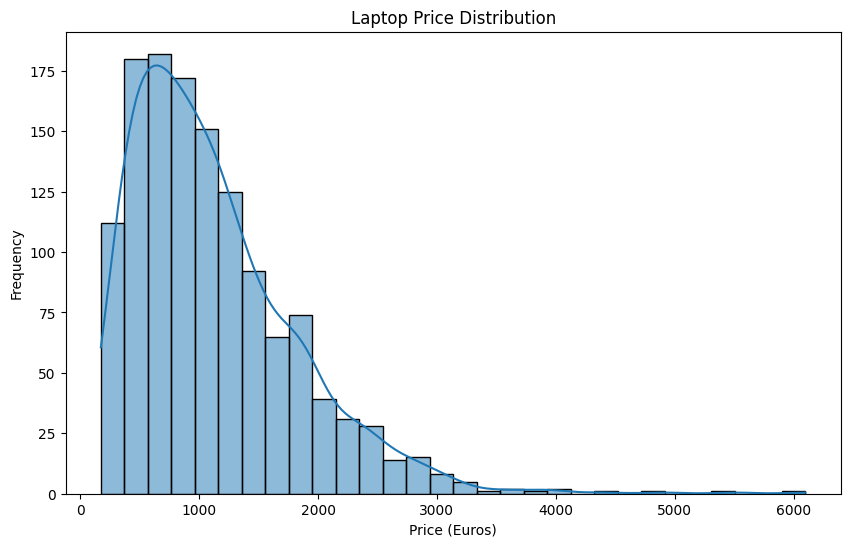

In [224]:
# Price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Price_euros'], bins=30, kde=True)

plt.title('Laptop Price Distribution')
plt.xlabel('Price (Euros)')
plt.ylabel('Frequency')
plt.show()

In [225]:
# Price segment distribution
price_segment_counts = df_clean['Price_Segment'].value_counts().sort_index()

price_segment_counts

Budget       329
Mid-Range    323
Premium      325
High-End     326
Name: Price_Segment, dtype: int64

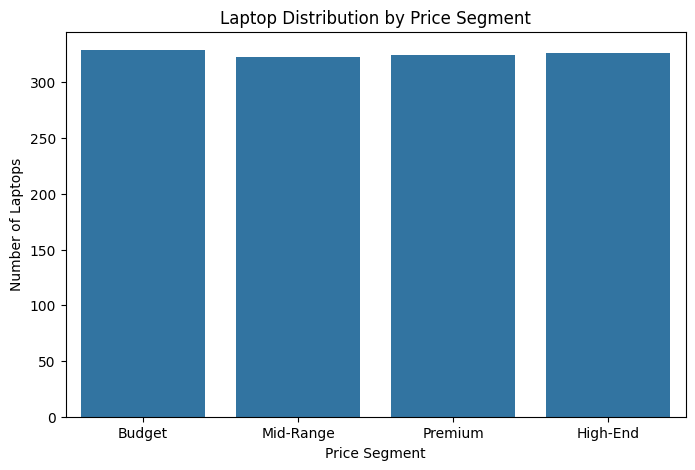

In [226]:
# Visualize price segment distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x='Price_Segment',
    order=['Budget', 'Mid-Range', 'Premium', 'High-End']
)

plt.title('Laptop Distribution by Price Segment')
plt.xlabel('Price Segment')
plt.ylabel('Number of Laptops')
plt.show()

Sebaran harga laptop pada dataset cukup lebar, mulai dari 174 euro hingga 6099 euro, dengan rata-rata harga sekitar 1123 euro dan median 977 euro. Distribusi harga terlihat condong ke kanan, artinya sebagian besar laptop berada pada rentang harga rendah hingga menengah, sementara hanya sedikit laptop yang berada pada harga sangat tinggi.

Hasil eksplorasi harga dapat digunakan sebagai dasar segmentasi rekomendasi karena pembagian berdasarkan kuartil menghasilkan empat segmen yang relatif seimbang, yaitu Low, Mid-Low, Mid-High, dan High. Segmentasi ini membantu membedakan laptop berdasarkan kemampuan budget pengguna, sehingga rekomendasi dapat lebih mudah diarahkan sesuai daya beli dan kebutuhan masing-masing user.

### Product Positioning Analysis

#### Brand Analysis

In [227]:
# Top laptop brands
brand_counts = df_clean['Company'].value_counts()

brand_counts

Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: Company, dtype: int64

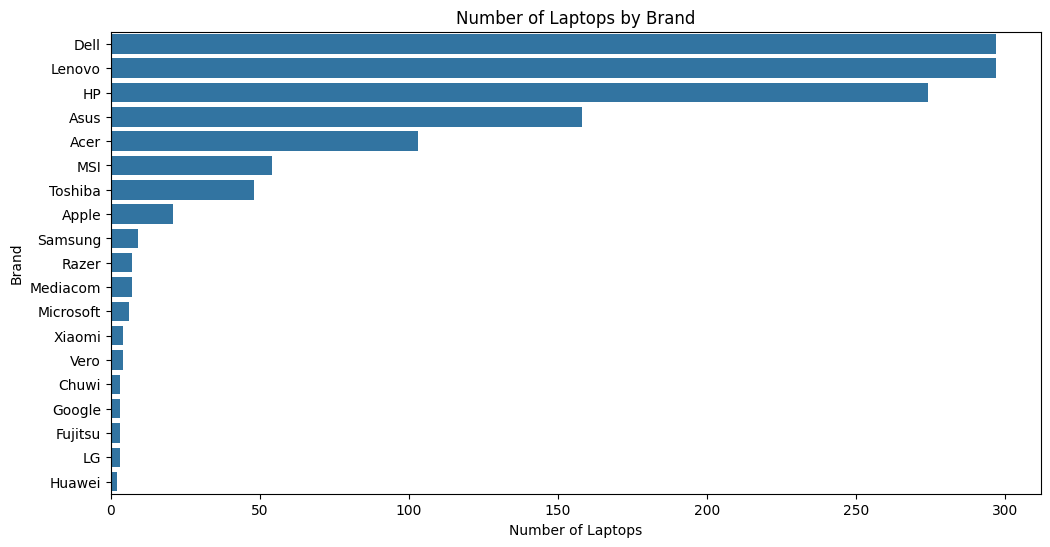

In [228]:
# Brand distribution
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_clean,
    y='Company',
    order=df_clean['Company'].value_counts().index
)

plt.title('Number of Laptops by Brand')
plt.xlabel('Number of Laptops')
plt.ylabel('Brand')
plt.show()

In [229]:
# Average price by brand
brand_price = df_clean.groupby('Company')['Price_euros'].mean().sort_values(ascending=False)

brand_price

Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1186.068990
Xiaomi       1133.462500
Asus         1104.169367
Lenovo       1086.384444
HP           1067.774854
Fujitsu       729.000000
Acer          626.775825
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price_euros, dtype: float64

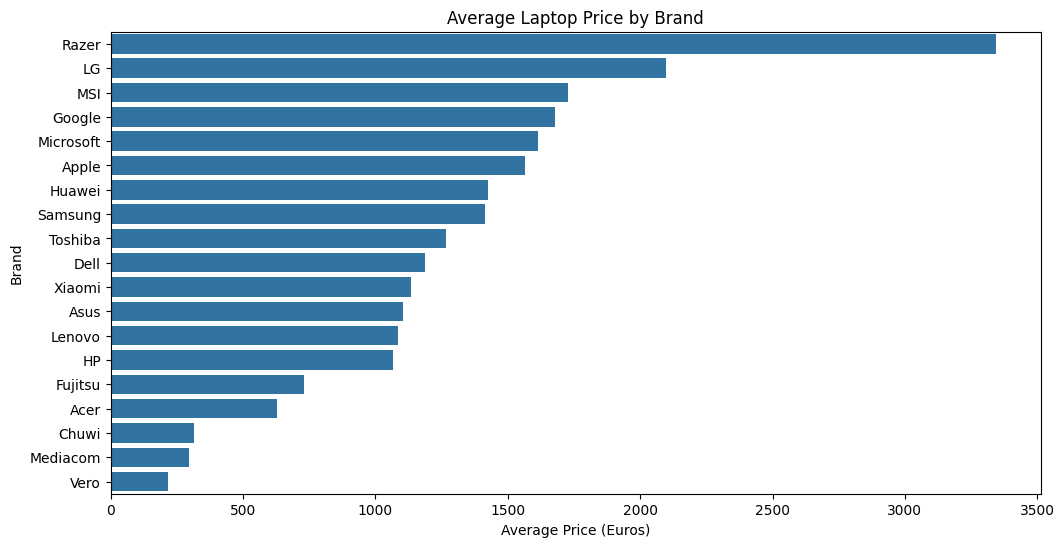

In [230]:
# Average price by brand visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_price.values, y=brand_price.index)

plt.title('Average Laptop Price by Brand')
plt.xlabel('Average Price (Euros)')
plt.ylabel('Brand')
plt.show()

#### Laptop Type Analysis

In [231]:
# Laptop type distribution
type_counts = df_clean['TypeName'].value_counts()

type_counts

Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: TypeName, dtype: int64

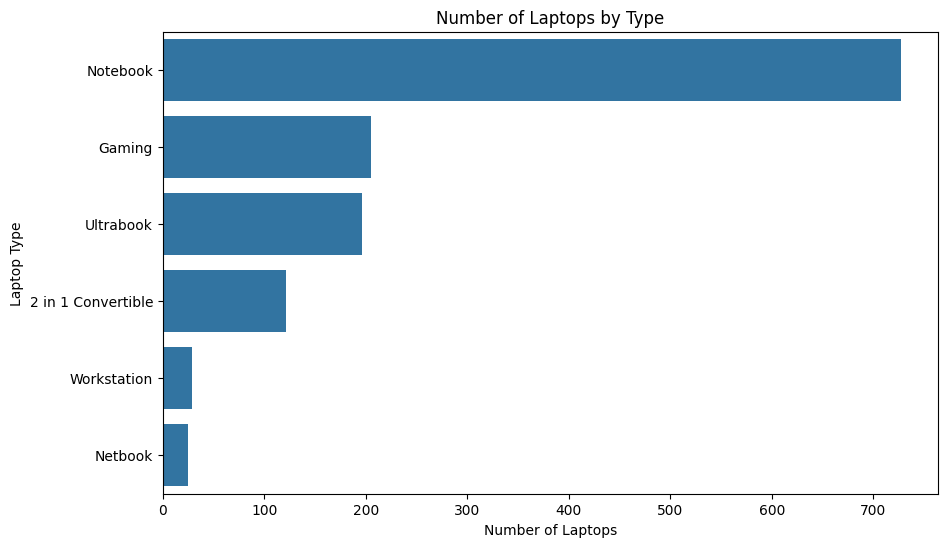

In [232]:
# Laptop type distribution visualization
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean,
    y='TypeName',
    order=df_clean['TypeName'].value_counts().index
)

plt.title('Number of Laptops by Type')
plt.xlabel('Number of Laptops')
plt.ylabel('Laptop Type')
plt.show()

In [233]:
# Average price by laptop type
type_price = df_clean.groupby('TypeName')['Price_euros'].mean().sort_values(ascending=False)

type_price

TypeName
Workstation           2280.358966
Gaming                1731.380634
Ultrabook             1548.230357
2 in 1 Convertible    1282.401653
Notebook               782.078624
Netbook                636.232000
Name: Price_euros, dtype: float64

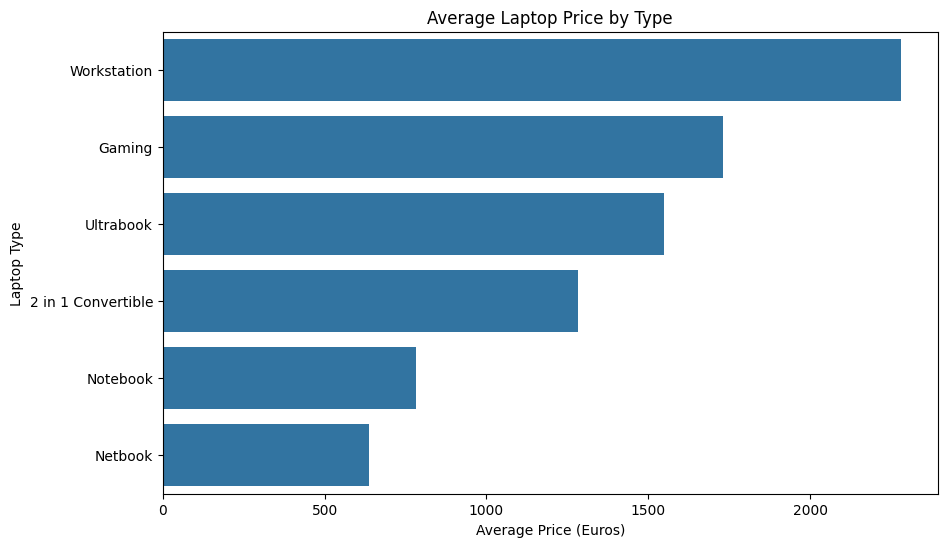

In [234]:
# Average price by laptop type visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=type_price.values, y=type_price.index)

plt.title('Average Laptop Price by Type')
plt.xlabel('Average Price (Euros)')
plt.ylabel('Laptop Type')
plt.show()

Berdasarkan hasil eksplorasi, brand yang paling banyak muncul dalam dataset adalah `Dell` dan `Lenovo`, masing-masing sebanyak 297 laptop, kemudian diikuti oleh `HP` sebanyak 274 laptop. Ini menunjukkan bahwa ketiga brand tersebut memiliki jumlah produk yang paling dominan dalam dataset.

Namun, jumlah produk yang banyak tidak selalu berarti memiliki rata-rata harga paling tinggi. Brand seperti `Razer`, `LG`, `MSI`, `Google`, `Microsoft`, dan `Apple` justru memiliki rata-rata harga yang lebih tinggi. Sementara itu, `Dell`, `Lenovo`, dan `HP` cenderung berada pada rentang harga menengah meskipun jumlah produknya paling banyak.

Dari sisi tipe laptop, `Notebook` menjadi tipe yang paling dominan dengan 727 unit. Jumlah ini jauh lebih besar dibandingkan `Gaming` sebanyak 205 unit dan `Ultrabook` sebanyak 196 unit. Hal ini menunjukkan bahwa Notebook merupakan tipe laptop yang paling umum tersedia dalam dataset.

Jika dilihat dari rata-rata harga, `Workstation` memiliki harga tertinggi, yaitu sekitar 2280 euro, diikuti oleh `Gaming` sekitar 1731 euro dan `Ultrabook` sekitar 1548 euro. Sebaliknya, `Notebook` dan `Netbook` memiliki rata-rata harga yang lebih rendah.

Dengan demikian, brand dan tipe laptop sama-sama berperan dalam membentuk posisi harga. Brand tertentu cenderung berada di segmen premium, tetapi tipe laptop terlihat lebih jelas dalam membedakan positioning produk. `Workstation`, `Gaming`, dan `Ultrabook` lebih identik dengan segmen premium, sedangkan `Notebook` lebih banyak merepresentasikan laptop umum atau mid-range.

### Performance Specification Analysis

#### RAM Analysis

In [235]:
# RAM distribution
df_clean['Ram_GB'].value_counts().sort_index()

2      22
4     375
6      41
8     619
12     25
16    200
24      3
32     17
64      1
Name: Ram_GB, dtype: int64

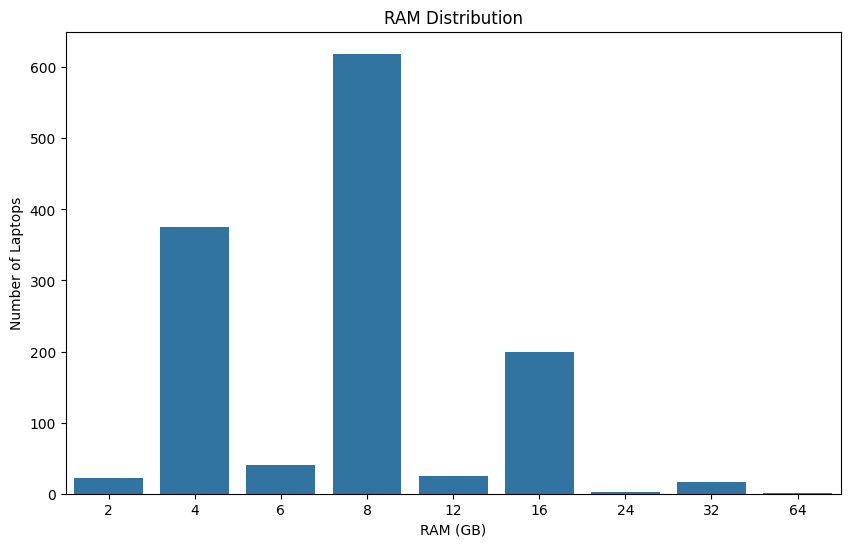

In [236]:
# RAM distribution visualization
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean,
    x='Ram_GB',
    order=sorted(df_clean['Ram_GB'].unique())
)

plt.title('RAM Distribution')
plt.xlabel('RAM (GB)')
plt.ylabel('Number of Laptops')
plt.show()

In [237]:
# Average price by RAM
ram_price = df_clean.groupby('Ram_GB')['Price_euros'].mean().sort_index()

ram_price

Ram_GB
2      254.370455
4      574.572480
6      615.206341
8     1180.812940
12    1239.438400
16    1936.771150
24    2206.333333
32    3413.085882
64    3975.000000
Name: Price_euros, dtype: float64

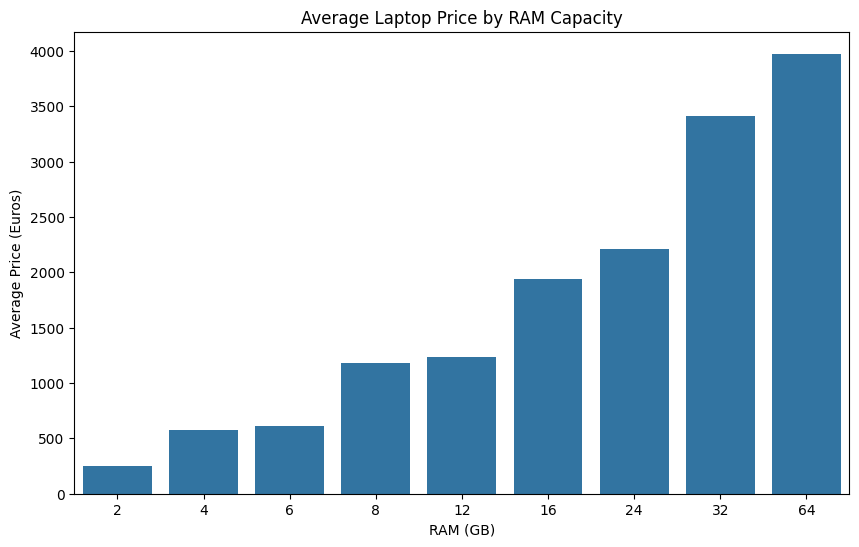

In [238]:
# Average price by RAM visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=ram_price.index, y=ram_price.values)

plt.title('Average Laptop Price by RAM Capacity')
plt.xlabel('RAM (GB)')
plt.ylabel('Average Price (Euros)')
plt.show()

#### CPU Analysis

In [239]:
# CPU category distribution
df_clean['CPU_Category'].value_counts()

Intel Core i7      527
Intel Core i5      423
Intel Core i3      136
Intel Celeron       88
Other Processor     63
Intel Pentium       30
Intel Core M        19
Intel Atom          13
AMD Ryzen            4
Name: CPU_Category, dtype: int64

In [240]:
# Average price by CPU category
cpu_price = df_clean.groupby('CPU_Category')['Price_euros'].mean().sort_values(ascending=False)

cpu_price

CPU_Category
AMD Ryzen          1685.500000
Intel Core i7      1595.779108
Intel Core M       1324.231579
Intel Core i5      1015.015248
Other Processor     682.739841
Intel Core i3       541.625956
Intel Pentium       435.540000
Intel Celeron       319.328523
Intel Atom          314.912308
Name: Price_euros, dtype: float64

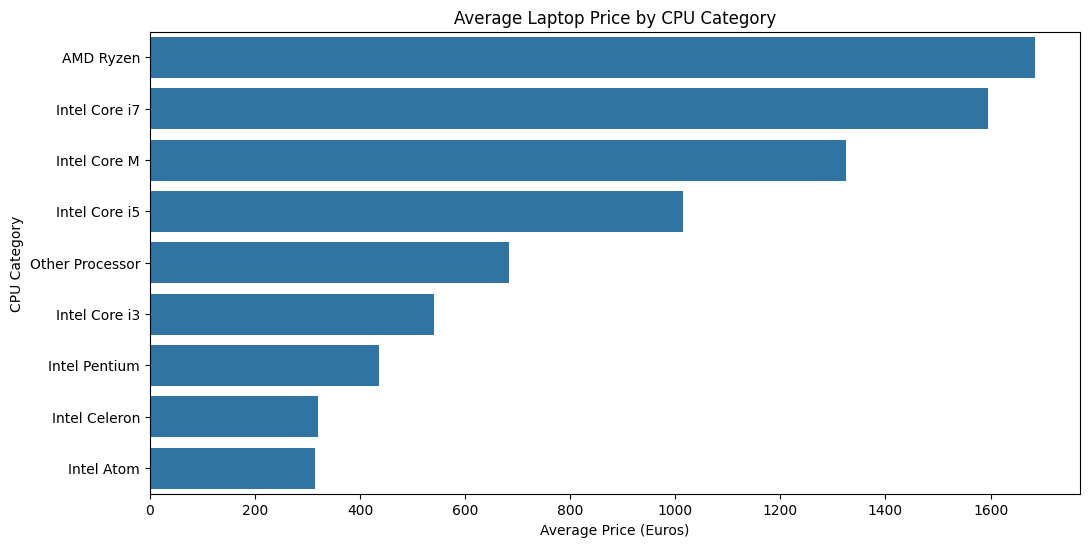

In [241]:
# Average price by CPU category visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=cpu_price.values, y=cpu_price.index)

plt.title('Average Laptop Price by CPU Category')
plt.xlabel('Average Price (Euros)')
plt.ylabel('CPU Category')
plt.show()

#### GPU Analysis

In [242]:
# GPU type distribution
df_clean['GPU_Type'].value_counts()

Integrated    722
Dedicated     581
Name: GPU_Type, dtype: int64

In [243]:
# Average price by GPU type
gpu_type_price = df_clean.groupby('GPU_Type')['Price_euros'].mean().sort_values(ascending=False)

gpu_type_price

GPU_Type
Dedicated     1267.169157
Integrated    1008.225582
Name: Price_euros, dtype: float64

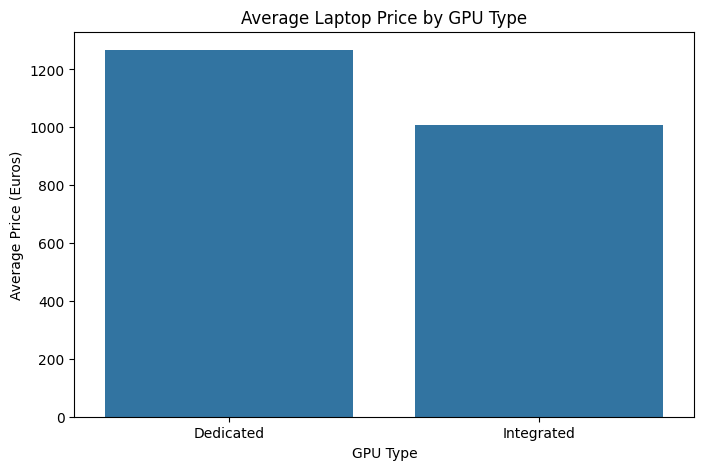

In [244]:
# Average price by GPU type visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=gpu_type_price.index, y=gpu_type_price.values)

plt.title('Average Laptop Price by GPU Type')
plt.xlabel('GPU Type')
plt.ylabel('Average Price (Euros)')
plt.show()

#### Storage Analysis

In [245]:
# Storage type distribution
df_clean['Storage_Type'].value_counts()

SSD              643
HDD              376
SSD + HDD        200
Flash Storage     74
Hybrid            10
Name: Storage_Type, dtype: int64

In [246]:
# Average price by storage type
storage_price = df_clean.groupby('Storage_Type')['Price_euros'].mean().sort_values(ascending=False)

storage_price

Storage_Type
SSD + HDD        1613.456450
SSD              1318.908429
Hybrid            810.746000
HDD               658.855479
Flash Storage     507.805676
Name: Price_euros, dtype: float64

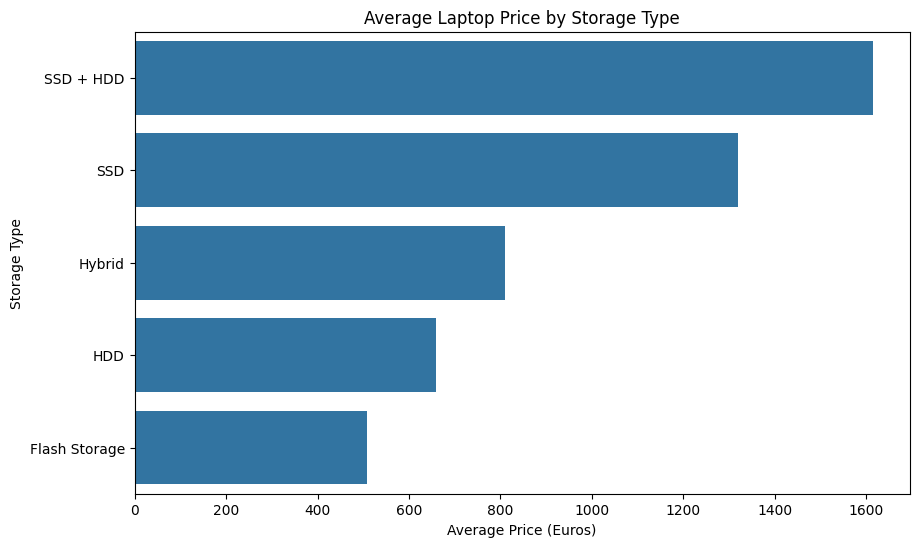

In [247]:
# Average price by storage type visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=storage_price.values, y=storage_price.index)

plt.title('Average Laptop Price by Storage Type')
plt.xlabel('Average Price (Euros)')
plt.ylabel('Storage Type')
plt.show()

Berdasarkan hasil analisis spesifikasi performa, RAM menjadi salah satu pembeda utama karakteristik laptop. Mayoritas laptop dalam dataset menggunakan RAM 8GB sebanyak 619 unit, diikuti RAM 4GB sebanyak 375 unit dan 16GB sebanyak 200 unit. Dari sisi harga, semakin besar kapasitas RAM, rata-rata harga laptop juga cenderung meningkat. Laptop dengan RAM 2GB dan 4GB berada pada segmen harga rendah, sedangkan RAM 16GB ke atas mulai menunjukkan karakteristik laptop performa tinggi.

Dari sisi CPU, kategori yang paling banyak digunakan adalah Intel Core i7 sebanyak 527 unit dan Intel Core i5 sebanyak 423 unit. Rata-rata harga tertinggi terdapat pada AMD Ryzen sekitar 1685 euro, kemudian Intel Core i7 sekitar 1596 euro. Sementara itu, Intel Celeron, Intel Atom, dan Intel Pentium memiliki rata-rata harga yang lebih rendah. Ini menunjukkan bahwa prosesor kelas tinggi seperti Ryzen dan Core i7 lebih cocok untuk kebutuhan performa berat, sedangkan Celeron, Atom, dan Pentium lebih sesuai untuk kebutuhan basic.

Untuk GPU, jumlah laptop dengan integrated GPU sedikit lebih banyak, yaitu 722 unit, dibandingkan dedicated GPU sebanyak 581 unit. Namun, rata-rata harga laptop dengan dedicated GPU lebih tinggi, sekitar 1267 euro, dibandingkan integrated GPU sekitar 1008 euro. Artinya, dedicated GPU menjadi indikator penting untuk laptop yang ditujukan bagi kebutuhan grafis, gaming, desain, atau pekerjaan kreatif.

Dari sisi storage, SSD menjadi tipe penyimpanan paling dominan dengan 643 unit, diikuti HDD sebanyak 376 unit dan kombinasi SSD + HDD sebanyak 200 unit. Rata-rata harga tertinggi terdapat pada laptop dengan SSD + HDD sekitar 1613 euro, kemudian SSD sekitar 1319 euro. Sementara itu, HDD dan Flash Storage memiliki rata-rata harga lebih rendah. Hal ini menunjukkan bahwa laptop dengan SSD atau kombinasi SSD + HDD lebih mengarah ke kebutuhan performa dan produktivitas, sedangkan HDD atau Flash Storage lebih dekat dengan segmen basic atau budget.

Secara keseluruhan, RAM, CPU, GPU, dan storage dapat membedakan laptop berdasarkan kebutuhan performa. Laptop untuk penggunaan ringan biasanya cukup dengan RAM rendah, prosesor entry-level, integrated GPU, dan storage sederhana. Sebaliknya, laptop untuk gaming, creative work, multitasking berat, atau high performance cenderung memiliki RAM besar, CPU kelas atas, dedicated GPU, serta SSD atau kombinasi SSD + HDD.

### Portability and Display Analysis

#### Screen & Display Analysis

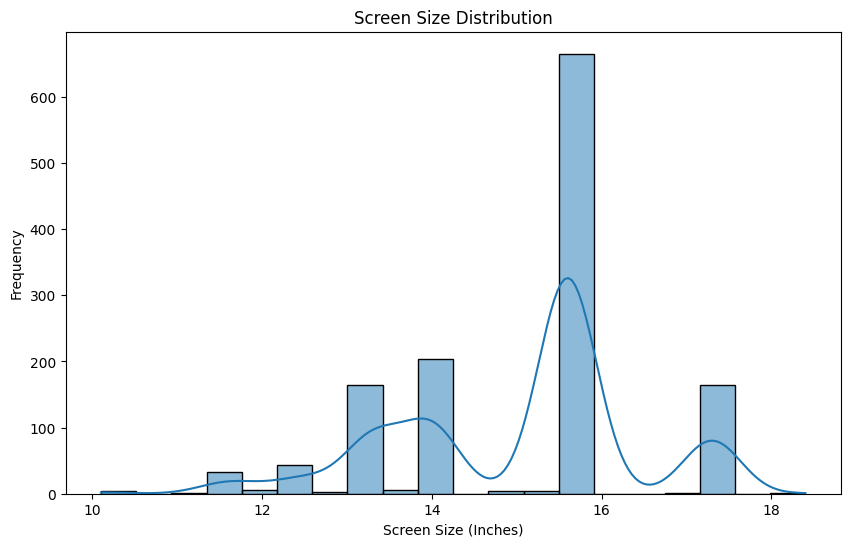

In [248]:
# Screen size distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Inches'], bins=20, kde=True)

plt.title('Screen Size Distribution')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Frequency')
plt.show()

In [249]:
# Average price by touchscreen feature
touch_price = df_clean.groupby('Touchscreen')['Price_euros'].mean().sort_values(ascending=False)

touch_price

Touchscreen
Yes    1445.105208
No     1068.140369
Name: Price_euros, dtype: float64

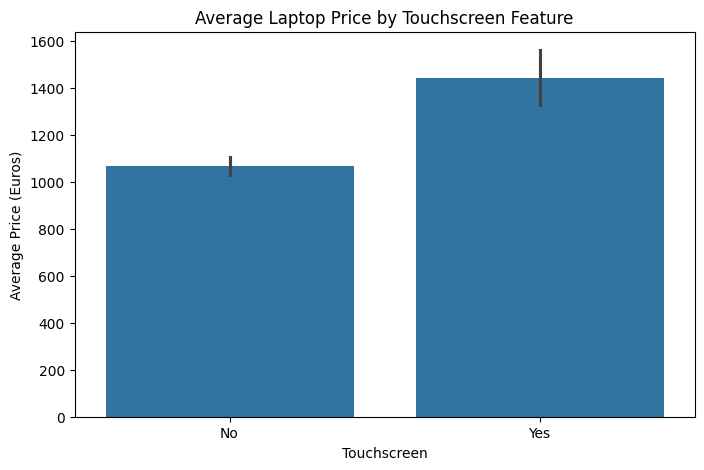

In [250]:
# Touchscreen average price visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='Touchscreen', y='Price_euros', estimator='mean')

plt.title('Average Laptop Price by Touchscreen Feature')
plt.xlabel('Touchscreen')
plt.ylabel('Average Price (Euros)')
plt.show()

In [251]:
# Average price by IPS panel feature
ips_price = df_clean.groupby('IPS_Panel')['Price_euros'].mean().sort_values(ascending=False)

ips_price

IPS_Panel
Yes    1406.194027
No     1013.756215
Name: Price_euros, dtype: float64

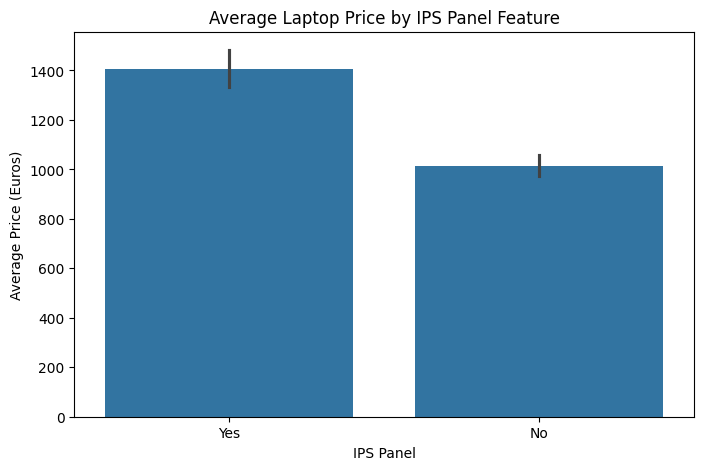

In [252]:
# IPS panel average price visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='IPS_Panel', y='Price_euros', estimator='mean')

plt.title('Average Laptop Price by IPS Panel Feature')
plt.xlabel('IPS Panel')
plt.ylabel('Average Price (Euros)')
plt.show()

#### Weight Analysis

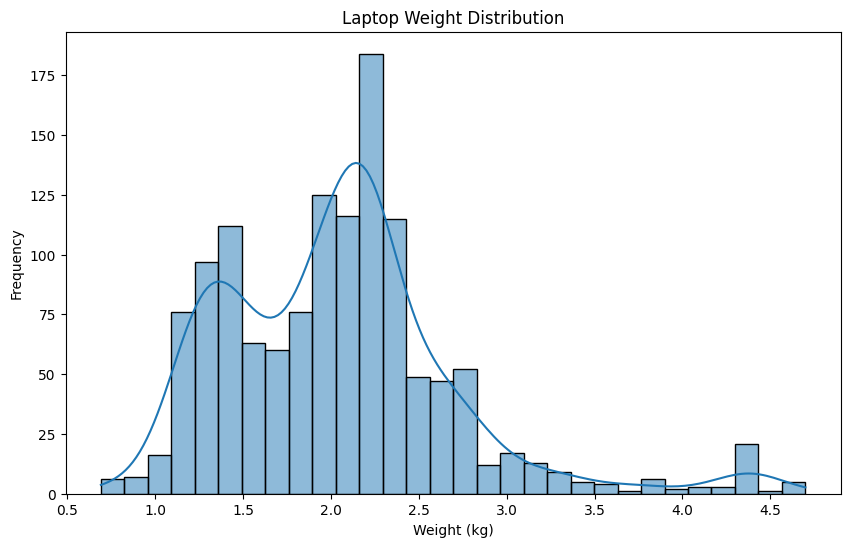

In [253]:
# Weight distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Weight_kg'], bins=30, kde=True)

plt.title('Laptop Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.show()

In [254]:
# Average weight by laptop type
type_weight = df_clean.groupby('TypeName')['Weight_kg'].mean().sort_values()

type_weight

TypeName
Netbook               1.306000
Ultrabook             1.343204
2 in 1 Convertible    1.546620
Notebook              2.059395
Workstation           2.466552
Gaming                2.949761
Name: Weight_kg, dtype: float64

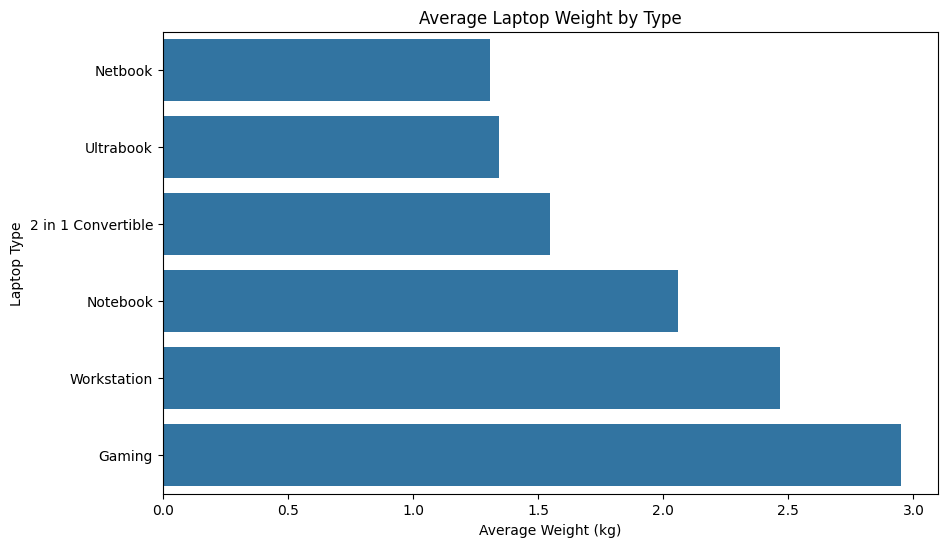

In [255]:
# Average weight by laptop type visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=type_weight.values, y=type_weight.index)

plt.title('Average Laptop Weight by Type')
plt.xlabel('Average Weight (kg)')
plt.ylabel('Laptop Type')
plt.show()

In [256]:
# Portability category distribution
df_clean['Portability_Category'].value_counts()

Portable           578
Less Portable      390
Highly Portable    335
Name: Portability_Category, dtype: int64

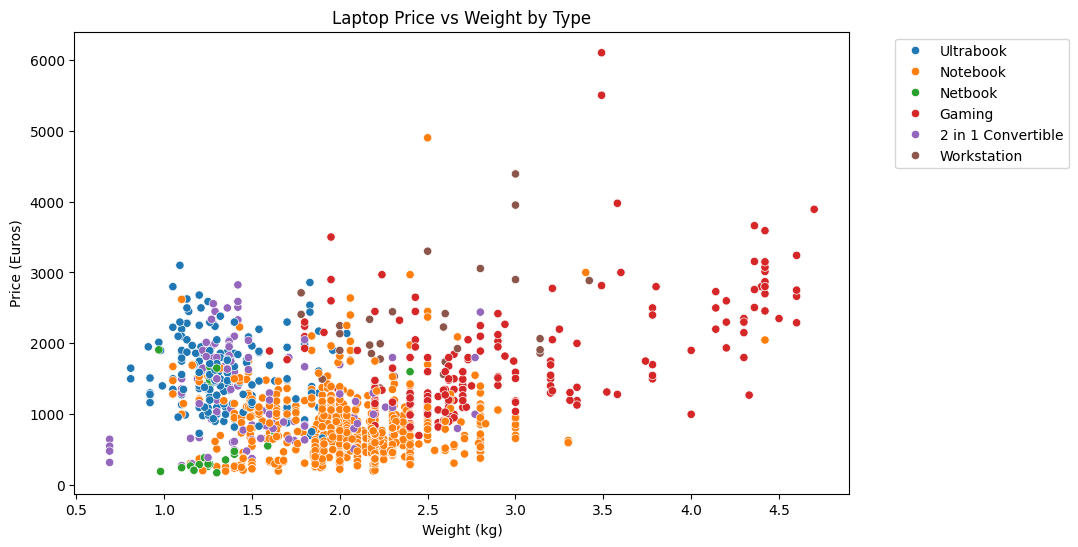

In [257]:
# Price vs weight by laptop type
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='Weight_kg',
    y='Price_euros',
    hue='TypeName'
)

plt.title('Laptop Price vs Weight by Type')
plt.xlabel('Weight (kg)')
plt.ylabel('Price (Euros)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Berdasarkan hasil analisis, ukuran layar laptop paling banyak berada di sekitar 15–16 inci, terutama 15.6 inci. Ukuran ini cukup ideal untuk penggunaan harian seperti bekerja, belajar, browsing, dan menonton, tetapi kurang optimal untuk pengguna yang sangat mobile. Laptop dengan layar lebih kecil cenderung lebih praktis dibawa, sedangkan layar besar lebih nyaman untuk produktivitas visual tetapi biasanya mengurangi portabilitas.

Dari sisi display, laptop dengan fitur `Touchscreen` dan `IPS_Panel` memiliki rata-rata harga lebih tinggi dibandingkan laptop tanpa fitur tersebut. Laptop touchscreen memiliki rata-rata harga sekitar 1445 euro, sedangkan non-touchscreen sekitar 1068 euro. Laptop dengan IPS panel juga lebih mahal, sekitar 1406 euro dibandingkan non-IPS sekitar 1014 euro. Hal ini menunjukkan bahwa fitur display tersebut lebih banyak ditemukan pada laptop dengan positioning lebih premium dan pengalaman visual yang lebih baik.

Dari sisi berat, mayoritas laptop berada pada rentang 1–2.5 kg. `Netbook` dan `Ultrabook` menjadi tipe paling ringan dengan rata-rata sekitar 1.3 kg, sehingga cocok untuk pengguna yang mengutamakan mobilitas. Sebaliknya, `Gaming` dan `Workstation` cenderung lebih berat karena membawa spesifikasi performa yang lebih tinggi.

Secara keseluruhan, kenyamanan penggunaan dipengaruhi oleh ukuran layar dan kualitas display, sedangkan portabilitas lebih banyak ditentukan oleh berat dan tipe laptop. Artinya, ada trade-off antara kenyamanan visual, performa, dan kemudahan dibawa.

### Recommendation Feature Relevance

In [258]:
# Correlation analysis for numerical features
numeric_cols = ['Inches', 'Ram_GB', 'Weight_kg', 'Price_euros']

corr_matrix = df_clean[numeric_cols].corr()

corr_matrix

,Inches,Ram_GB,Weight_kg,Price_euros
Inches,1.000000,0.237993,0.827631,0.068197
Ram_GB,0.237993,1.000000,0.383874,0.743007
Weight_kg,0.827631,0.383874,1.000000,0.210370
Price_euros,0.068197,0.743007,0.210370,1.000000


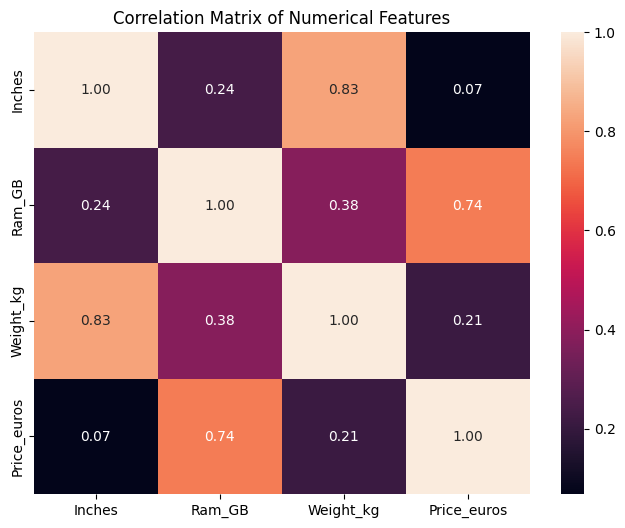

In [259]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [260]:
# Summary table for average price by selected categorical features
feature_price_summary = {
    'Laptop Type': df_clean.groupby('TypeName')['Price_euros'].mean().sort_values(ascending=False),
    'CPU Category': df_clean.groupby('CPU_Category')['Price_euros'].mean().sort_values(ascending=False),
    'GPU Type': df_clean.groupby('GPU_Type')['Price_euros'].mean().sort_values(ascending=False),
    'Storage Type': df_clean.groupby('Storage_Type')['Price_euros'].mean().sort_values(ascending=False),
    'Touchscreen': df_clean.groupby('Touchscreen')['Price_euros'].mean().sort_values(ascending=False),
    'IPS Panel': df_clean.groupby('IPS_Panel')['Price_euros'].mean().sort_values(ascending=False)
}

feature_price_summary

{'Laptop Type': TypeName
 Workstation           2280.358966
 Gaming                1731.380634
 Ultrabook             1548.230357
 2 in 1 Convertible    1282.401653
 Notebook               782.078624
 Netbook                636.232000
 Name: Price_euros, dtype: float64,
 'CPU Category': CPU_Category
 AMD Ryzen          1685.500000
 Intel Core i7      1595.779108
 Intel Core M       1324.231579
 Intel Core i5      1015.015248
 Other Processor     682.739841
 Intel Core i3       541.625956
 Intel Pentium       435.540000
 Intel Celeron       319.328523
 Intel Atom          314.912308
 Name: Price_euros, dtype: float64,
 'GPU Type': GPU_Type
 Dedicated     1267.169157
 Integrated    1008.225582
 Name: Price_euros, dtype: float64,
 'Storage Type': Storage_Type
 SSD + HDD        1613.456450
 SSD              1318.908429
 Hybrid            810.746000
 HDD               658.855479
 Flash Storage     507.805676
 Name: Price_euros, dtype: float64,
 'Touchscreen': Touchscreen
 Yes    1445.105208

Berdasarkan hasil analisis, fitur yang paling relevan untuk mendukung sistem rekomendasi berbasis content-based filtering adalah kombinasi antara fitur Performance specification, laptop type, price, storage, display, dan portability.

Dari fitur numerik, `Ram_GB` menjadi fitur yang sangat penting karena memiliki korelasi paling kuat dengan harga, yaitu sekitar 0.74. Artinya, kapasitas RAM cukup jelas membedakan kelas laptop, mulai dari kebutuhan basic hingga high performance. Selain itu, `Weight_kg` dan `Inches` juga relevan karena keduanya memiliki korelasi kuat sekitar 0.83, sehingga dapat digunakan untuk membedakan laptop yang lebih portable dengan laptop berlayar besar.

Dari fitur kategorikal, `TypeName`, `CPU_Category`, `GPU_Type`, `Storage_Type`, `Touchscreen`, dan `IPS_Panel` juga penting karena masing-masing menunjukkan perbedaan rata-rata harga dan karakteristik penggunaan. Misalnya, `Workstation`, `Gaming`, dan `Ultrabook` memiliki rata-rata harga lebih tinggi dibandingkan `Notebook` dan `Netbook`. CPU seperti `AMD Ryzen` dan `Intel Core i7`, dedicated GPU, serta storage `SSD + HDD` dan `SSD` juga lebih dekat dengan laptop berperforma tinggi.

Dengan demikian, fitur yang paling layak digunakan sebagai dasar rekomendasi adalah `Price_euros` atau `Price_Segment`, `TypeName`, `Ram_GB`, `CPU_Category`, `GPU_Type`, `Storage_Type`, `Weight_kg`, `Inches`, `Touchscreen`, dan `IPS_Panel`. Fitur-fitur ini dapat membantu sistem mencocokkan laptop dengan kebutuhan pengguna, misalnya berdasarkan budget, performa, portabilitas, dan kualitas display.

## EDA Summary

Berdasarkan hasil exploratory data analysis, variasi harga yang cukup lebar, mulai dari 174 euro hingga 6099 euro. Sebagian besar laptop berada pada rentang harga rendah hingga menengah, sedangkan hanya sedikit laptop yang berada pada harga sangat tinggi. Oleh karena itu, harga dapat digunakan sebagai dasar segmentasi awal melalui kategori Low, Mid-Low, Mid-High, dan High.

Dari sisi brand, `Dell`, `Lenovo`, dan `HP` menjadi brand yang paling dominan berdasarkan jumlah produk. Namun, brand dengan jumlah produk terbanyak tidak selalu memiliki rata-rata harga tertinggi. Brand seperti `Razer`, `LG`, `MSI`, `Google`, `Microsoft`, dan `Apple` cenderung berada pada segmen harga yang lebih premium. Dari sisi tipe laptop, `Notebook` menjadi tipe yang paling umum, sedangkan `Workstation`, `Gaming`, dan `Ultrabook` memiliki rata-rata harga lebih tinggi.

Spesifikasi performa seperti RAM, CPU, GPU, dan storage juga membedakan karakteristik laptop secara jelas. Laptop dengan RAM lebih besar, CPU kelas atas, GPU khusus/kartu grafis khusus, serta SSD atau SSD + HDD cenderung berada pada segmen performa dan harga yang lebih tinggi. Sebaliknya, laptop dengan RAM rendah, prosesor entry-level, integrated GPU, dan storage sederhana lebih dekat dengan kebutuhan basic atau budget.

Dari sisi kenyamanan dan kemudahan dibawa, ukuran layar paling umum berada di sekitar 15–16 inci. Laptop dengan `Touchscreen` dan `IPS_Panel` cenderung memiliki rata-rata harga lebih tinggi karena menawarkan pengalaman visual atau interaksi layar yang lebih baik. Sementara itu, berat laptop sangat berkaitan dengan portabilitas. `Netbook` dan `Ultrabook` lebih cocok untuk pengguna yang sering bepergian, sedangkan `Gaming` dan `Workstation` cenderung lebih berat karena membawa spesifikasi performa yang lebih tinggi.

Secara keseluruhan, fitur yang paling relevan untuk mendukung strategi rekomendasi laptop adalah `Price_Segment`, `TypeName`, `Ram_GB`, `CPU_Category`, `GPU_Type`, `Storage_Type`, `Weight_kg`, `Inches`, `Touchscreen`, dan `IPS_Panel`. Fitur-fitur tersebut dapat membantu memetakan laptop berdasarkan kebutuhan pengguna seperti budget, performa, kenyamanan penggunaan, dan kemudahan dibawa.

# User Need Mapping

Pendekatan ini untuk menerjemahkan hasil EDA menjadi kategori kebutuhan pengguna yang lebih mudah dipahami. Dengan begitu, spesifikasi teknis laptop dapat dikaitkan dengan kebutuhan praktis seperti penggunaan basic, office, gaming, desain, mobilitas (on-the-go), dan professional.

In [261]:
# Define user need categories based on analysis results
user_need_mapping = pd.DataFrame({
    'Users': [
        'Student / Basic User',
        'Office / Business User',
        'Gaming User',
        'Creative / Design User',
        'On-the-Go User / Remote Worker User',
        'Professional User'
    ],
    'User_Need': [
        'Laptop terjangkau untuk belajar, browsing, dan produktivitas ringan',
        'Laptop seimbang untuk pekerjaan kantor, multitasking, dan produktivitas harian',
        'Laptop dengan performa grafis tinggi untuk gaming',
        'Laptop dengan kualitas visual dan performa yang baik untuk desain atau pekerjaan kreatif',
        'Laptop ringan dan mudah dibawa untuk pengguna dengan mobilitas tinggi',
        'Laptop dengan kemampuan komputasi tinggi untuk pekerjaan berat'
    ],
    'Fitur_Relevan': [
        'Price segment Low sampai Mid-Low, RAM 4-8GB, integrated GPU',
        'RAM minimal 8GB, SSD, CPU menengah ke atas, berat portable',
        'Dedicated GPU, RAM besar, CPU kuat, layar lebih besar, SSD atau SSD + HDD',
        'IPS panel, dedicated GPU, RAM tinggi, SSD, CPU kuat',
        'Ultrabook atau Netbook, berat sekitar 1.5 kg atau kurang, layar kecil hingga sedang',
        'Intel Core i7 atau AMD Ryzen, RAM 16GB atau lebih, dedicated GPU, SSD atau SSD + HDD'
    ]
})

user_need_mapping

,Users,User_Need,Fitur_Relevan
0,Student / Basic User,"Laptop terjangkau untuk belajar, browsing, dan...","Price segment Low sampai Mid-Low, RAM 4-8GB, i..."
1,Office / Business User,"Laptop seimbang untuk pekerjaan kantor, multit...","RAM minimal 8GB, SSD, CPU menengah ke atas, be..."
2,Gaming User,Laptop dengan performa grafis tinggi untuk gaming,"Dedicated GPU, RAM besar, CPU kuat, layar lebi..."
3,Creative / Design User,Laptop dengan kualitas visual dan performa yan...,"IPS panel, dedicated GPU, RAM tinggi, SSD, CPU..."
4,On-the-Go User / Remote Worker User,Laptop ringan dan mudah dibawa untuk pengguna ...,"Ultrabook atau Netbook, berat sekitar 1.5 kg a..."
5,Professional User,Laptop dengan kemampuan komputasi tinggi untuk...,"Intel Core i7 atau AMD Ryzen, RAM 16GB atau le..."


In [262]:
# Create user need category based on laptop characteristics
def map_user_need(row):
    
    # Gaming laptops have specific graphics and performance needs
    if row['TypeName'] == 'Gaming':
        return 'Gaming User'
    
    # Highly mobile users need lightweight laptop types
    elif row['Weight_kg'] <= 1.5 and row['TypeName'] in ['Ultrabook', 'Netbook']:
        return 'On-the-Go User / Remote Worker User'
    
    # Creative users need better display quality and graphics capability
    elif row['IPS_Panel'] == 'Yes' and row['GPU_Type'] == 'Dedicated':
        return 'Creative / Design User'
    
    # High performance users need strong RAM and CPU
    elif row['Ram_GB'] >= 16 and row['CPU_Category'] in ['Intel Core i7', 'AMD Ryzen']:
        return 'Professional User'
    
    # Student or basic users are more budget-sensitive
    elif row['Price_Segment'] in ['Low', 'Mid-Low'] and row['Ram_GB'] <= 8 and row['GPU_Type'] == 'Integrated':
        return 'Student / Basic User'
    
    # Office users need balanced specifications for productivity
    elif row['Ram_GB'] >= 8 and row['Storage_Type'] in ['SSD', 'SSD + HDD']:
        return 'Office / Business User'
    
    else:
        return 'General User'

# Apply rule-based mapping
df_clean['User_Need_Category'] = df_clean.apply(map_user_need, axis=1)

# Display sample result
df_clean[['Company', 'TypeName', 'Ram_GB', 'CPU_Category', 'GPU_Type',
          'Storage_Type', 'Weight_kg', 'Price_Segment', 'User_Need_Category']].head()

,Company,TypeName,Ram_GB,CPU_Category,GPU_Type,Storage_Type,Weight_kg,Price_Segment,User_Need_Category
0,Apple,Ultrabook,8,Intel Core i5,Integrated,SSD,1.37,Premium,On-the-Go User / Remote Worker User
1,Apple,Ultrabook,8,Intel Core i5,Integrated,Flash Storage,1.34,Mid-Range,On-the-Go User / Remote Worker User
2,HP,Notebook,8,Intel Core i5,Integrated,SSD,1.86,Budget,Office / Business User
3,Apple,Ultrabook,16,Intel Core i7,Dedicated,SSD,1.83,High-End,Creative / Design User
4,Apple,Ultrabook,8,Intel Core i5,Integrated,SSD,1.37,High-End,On-the-Go User / Remote Worker User


In [263]:
# Check distribution of user need categories
user_need_counts = df_clean['User_Need_Category'].value_counts()

user_need_counts

General User                           500
Office / Business User                 284
Gaming User                            205
On-the-Go User / Remote Worker User    179
Creative / Design User                  79
Professional User                       56
Name: User_Need_Category, dtype: int64

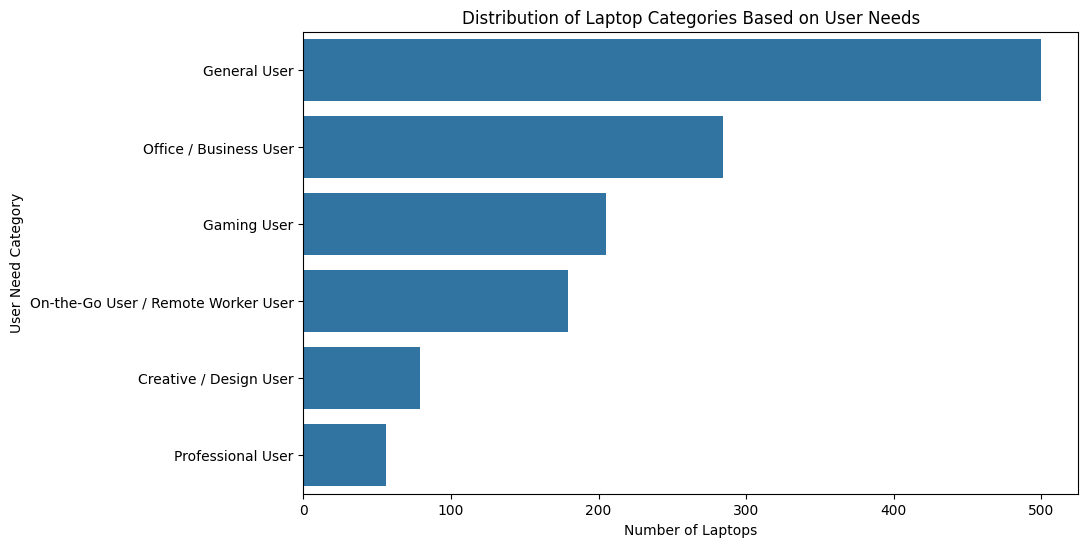

In [264]:
# Visualize user need distribution
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean,
    y='User_Need_Category',
    order=df_clean['User_Need_Category'].value_counts().index
)

plt.title('Distribution of Laptop Categories Based on User Needs')
plt.xlabel('Number of Laptops')
plt.ylabel('User Need Category')
plt.show()

In [265]:
# Average price by user need category
user_need_price = df_clean.groupby('User_Need_Category')['Price_euros'].mean().sort_values(ascending=False)

user_need_price

User_Need_Category
Professional User                      1768.216250
Gaming User                            1731.380634
On-the-Go User / Remote Worker User    1456.648380
Creative / Design User                 1426.336456
Office / Business User                 1195.110634
General User                            594.757900
Name: Price_euros, dtype: float64

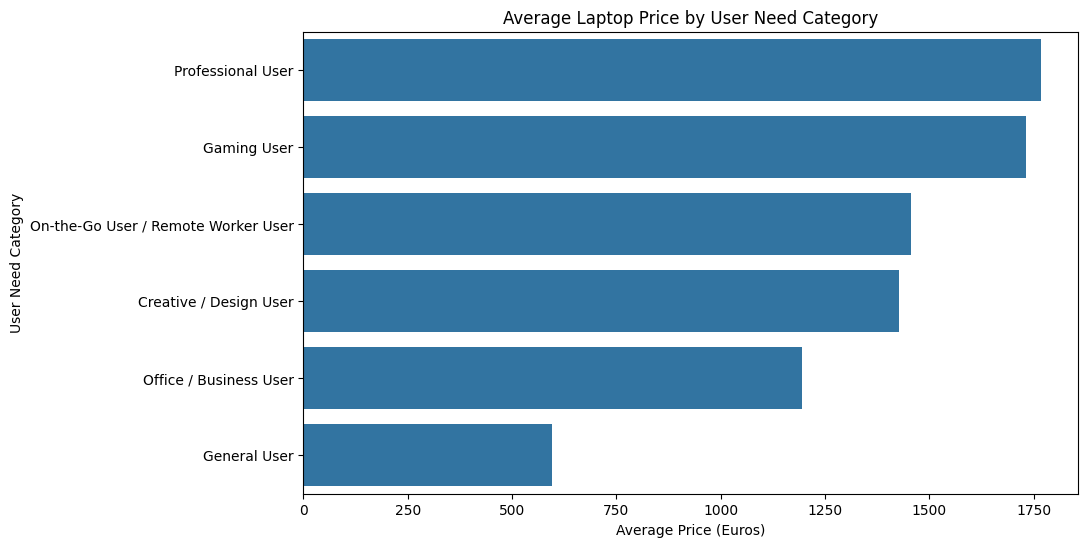

In [266]:
# Visualize average price by user need category
plt.figure(figsize=(10, 6))
sns.barplot(
    x=user_need_price.values,
    y=user_need_price.index
)

plt.title('Average Laptop Price by User Need Category')
plt.xlabel('Average Price (Euros)')
plt.ylabel('User Need Category')
plt.show()

In [267]:
# Specification profile by user need category
user_need_profile = df_clean.groupby('User_Need_Category').agg({
    'Price_euros': 'mean',
    'Ram_GB': 'mean',
    'Weight_kg': 'mean',
    'Inches': 'mean',
    'laptop_ID': 'count'
}).round(2)

user_need_profile = user_need_profile.rename(columns={
    'Price_euros': 'Avg_Price_Euros',
    'Ram_GB': 'Avg_RAM_GB',
    'Weight_kg': 'Avg_Weight_kg',
    'Inches': 'Avg_Screen_Size',
    'laptop_ID': 'Number_of_Laptops'
}).sort_values(by='Avg_Price_Euros', ascending=False)

user_need_profile

,Avg_Price_Euros,Avg_RAM_GB,Avg_Weight_kg,Avg_Screen_Size,Number_of_Laptops
User_Need_Category,,,,,
Professional User,1768.22,16.29,1.96,15.01,56
Gaming User,1731.38,14.05,2.95,16.35,205
On-the-Go User / Remote Worker User,1456.65,8.87,1.24,13.12,179
Creative / Design User,1426.34,9.29,2.28,15.72,79
Office / Business User,1195.11,8.14,1.85,14.79,284
General User,594.76,4.99,2.03,15.17,500


Berdasarkan hasil User Need Mapping, kategori laptop paling banyak adalah `Student / Basic User` sebanyak 360 unit. Kategori berikutnya adalah `Office / Business User` sebanyak 223 unit, `Gaming User` sebanyak 205 unit, dan `General User` sebanyak 201 unit. Artinya, selain kebutuhan basic, hasil eksplorasi juga cukup kuat merepresentasikan laptop untuk kebutuhan kerja harian dan gaming.

Dari sisi harga rata-rata, `Professional User` memiliki harga paling tinggi, yaitu sekitar 1768 euro, diikuti oleh `Gaming User` sekitar 1731 euro. Hal ini masuk akal karena kedua kategori ini membutuhkan spesifikasi yang lebih kuat, seperti RAM besar, CPU kelas atas, dedicated GPU, dan storage yang lebih baik. Sebaliknya, `Student / Basic User` memiliki rata-rata harga paling rendah, sekitar 558 euro, karena spesifikasinya lebih sederhana dan lebih fokus pada keterjangkauan harga.

Jika dilihat dari profil spesifikasi, `Professional User` memiliki rata-rata RAM tertinggi, yaitu sekitar 16.29GB, dengan berat rata-rata 1.96 kg dan ukuran layar sekitar 15 inci. Ini menunjukkan bahwa kategori ini lebih mengutamakan kemampuan komputasi untuk pekerjaan berat. Sementara itu, `Gaming User` memiliki rata-rata berat paling tinggi, yaitu sekitar 2.95 kg, dengan ukuran layar terbesar sekitar 16.35 inci. Artinya, laptop gaming cenderung lebih besar dan berat karena membutuhkan komponen performa tinggi.

Kategori `On-the-Go User / Remote Worker User` memiliki rata-rata berat paling ringan, yaitu sekitar 1.24 kg, dengan ukuran layar sekitar 13.12 inci. Ini menunjukkan bahwa kategori ini paling cocok untuk pengguna yang sering bepergian atau bekerja secara mobile karena lebih mudah dibawa. Di sisi lain, `Student / Basic User` memiliki rata-rata RAM sekitar 5.08GB dan harga paling rendah, sehingga lebih sesuai untuk kebutuhan ringan.

Secara keseluruhan, hasil mapping ini menunjukkan bahwa setiap kategori pengguna memiliki karakteristik laptop yang berbeda. Pengguna basic lebih sensitif terhadap harga, pengguna office membutuhkan spesifikasi yang seimbang, pengguna gaming dan professional membutuhkan performa lebih tinggi, sedangkan pengguna on-the-go lebih mengutamakan laptop yang ringan dan praktis dibawa.

# Key Findings

1. Harga laptop sangat bervariasi, mulai dari segmen rendah hingga premium. Hal ini menunjukkan bahwa `Price_Segment` dapat digunakan sebagai dasar awal untuk membantu pengguna memilih laptop sesuai budget.

2. Brand yang paling banyak muncul adalah `Dell`, `Lenovo`, dan `HP`. Namun, brand dengan jumlah produk terbanyak tidak selalu memiliki rata-rata harga tertinggi. Brand seperti `Razer`, `LG`, `MSI`, `Google`, `Microsoft`, dan `Apple` cenderung berada pada segmen harga yang lebih premium.

3. Tipe laptop berperan penting dalam membedakan positioning produk. `Notebook` menjadi tipe yang paling umum, sedangkan `Workstation`, `Gaming`, dan `Ultrabook` memiliki rata-rata harga lebih tinggi dibandingkan tipe lainnya.

4. Spesifikasi performa seperti RAM, CPU, GPU, dan storage menjadi pembeda utama karakteristik laptop. Laptop dengan RAM besar, CPU kelas atas, GPU khusus/kartu grafis khusus, serta SSD atau SSD + HDD cenderung cocok untuk kebutuhan berat seperti gaming, desain, multitasking, dan pekerjaan teknis.

5. Berdasarkan correlation heatmap, `Ram_GB` memiliki hubungan paling kuat dengan harga laptop dibandingkan fitur numerik lainnya, dengan korelasi sebesar 0.74 terhadap `Price_euros`. Artinya, semakin besar kapasitas RAM, harga laptop cenderung meningkat.

6. Ukuran layar tidak memiliki hubungan kuat dengan harga, karena korelasinya terhadap `Price_euros` hanya sekitar 0.07. Namun, ukuran layar sangat berkaitan dengan berat laptop, dengan korelasi sebesar 0.83 antara `Inches` dan `Weight_kg`.

7. Fitur display seperti `Touchscreen` dan `IPS_Panel` memiliki rata-rata harga lebih tinggi dibandingkan laptop tanpa fitur tersebut. Ini menunjukkan bahwa fitur display dapat menjadi indikator pengalaman penggunaan yang lebih premium.

8. Dari hasil User Need Mapping, kategori terbanyak adalah `Student / Basic User` sebanyak 360 unit, diikuti `Office / Business User` sebanyak 223 unit, `Gaming User` sebanyak 205 unit, dan `General User` sebanyak 201 unit. Ini menunjukkan bahwa dataset banyak merepresentasikan laptop untuk kebutuhan dasar, kerja harian, dan gaming.

9. `Professional User` memiliki rata-rata harga tertinggi sekitar 1768 euro, sedangkan `Student / Basic User` memiliki rata-rata harga paling rendah sekitar 558 euro. Ini menunjukkan bahwa kebutuhan pengguna sangat berkaitan dengan perbedaan spesifikasi dan harga laptop.

10. Secara keseluruhan, fitur yang paling relevan untuk mendukung strategi rekomendasi laptop adalah `Price_Segment`, `TypeName`, `Ram_GB`, `CPU_Category`, `GPU_Type`, `Storage_Type`, `Weight_kg`, `Inches`, `Touchscreen`, `IPS_Panel`, dan `User_Need_Category`.

# Business Insight Summary

1. **Segmentasi harga dapat membantu pengguna memilih laptop sesuai budget**  
   Harga laptop dalam dataset sangat bervariasi, sehingga `Price_Segment` dapat dijadikan filter awal. Dengan membagi laptop ke dalam segmen Low, Mid-Low, Mid-High, dan High, pengguna bisa lebih mudah mempersempit pilihan berdasarkan kemampuan budget.

2. **Brand tidak cukup untuk menjadi dasar rekomendasi**  
   `Dell`, `Lenovo`, dan `HP` adalah brand dengan jumlah produk terbanyak, tetapi rata-rata harga tertinggi justru dimiliki oleh brand seperti `Razer`, `LG`, `MSI`, `Google`, `Microsoft`, dan `Apple`. Artinya, rekomendasi laptop tidak sebaiknya hanya mengandalkan brand, tetapi perlu digabungkan dengan tipe laptop dan spesifikasi utama.

3. **Tipe laptop menunjukkan positioning dan kebutuhan pengguna**  
   `Notebook` menjadi tipe laptop paling umum dan lebih dekat dengan kebutuhan harian. Sementara itu, `Workstation`, `Gaming`, dan `Ultrabook` cenderung berada pada segmen harga lebih tinggi karena memiliki fungsi yang lebih spesifik, seperti performa berat, gaming, profesional, atau kebutuhan perangkat premium.

4. **Spesifikasi performa perlu menjadi filter utama**  
   RAM, CPU, GPU, dan storage sangat penting dalam membedakan laptop untuk kebutuhan ringan, menengah, atau berat. Laptop dengan RAM besar, CPU kelas atas, GPU khusus/kartu grafis khusus, serta SSD atau SSD + HDD lebih cocok untuk gaming, desain, pekerjaan data, programming, dan multitasking berat.

5. **Portabilitas dan kualitas display memengaruhi pengalaman pengguna**  
   Berat, ukuran layar, touchscreen, dan IPS panel perlu dipertimbangkan karena berhubungan dengan kenyamanan penggunaan. Pengguna yang sering bepergian lebih cocok dengan laptop ringan seperti ultrabook atau netbook, sedangkan pengguna desain, presentasi, atau multimedia dapat lebih mempertimbangkan IPS panel dan touchscreen.

6. **Strategi rekomendasi sebaiknya berbasis kebutuhan pengguna**  
   Hasil User Need Mapping menunjukkan bahwa tiap kategori pengguna memiliki karakteristik laptop yang berbeda. `Student / Basic User` lebih cocok dengan laptop terjangkau, `Office / Business User` membutuhkan spesifikasi seimbang, `Gaming User` dan `Professional User` membutuhkan performa lebih tinggi, sedangkan `On-the-Go User / Remote Worker User` membutuhkan laptop ringan dan praktis dibawa.

7. **Dashboard atau sistem rekomendasi perlu menggunakan filter yang mudah dipahami**  
   Agar lebih user-friendly, filter rekomendasi sebaiknya tidak hanya menampilkan istilah teknis, tetapi juga pilihan berdasarkan kebutuhan seperti belajar, kerja kantor, gaming, desain, kerja remote, atau pekerjaan teknis. Dengan begitu, pengguna dapat memilih laptop berdasarkan tujuan penggunaan, bukan hanya berdasarkan spesifikasi teknis.

# Recommendation Strategy

Berdasarkan hasil analisis, strategi recommendation engine (laptop) sebaiknya dibuat berdasarkan kebutuhan pengguna, bukan hanya berdasarkan brand atau harga. Setiap kategori pengguna memiliki prioritas yang berbeda, sehingga fitur rekomendasi perlu disesuaikan dengan tujuan penggunaan, budget, performa, portabilitas, dan kualitas display.

| User Segment | Kebutuhan Utama | Strategi Rekomendasi |
|---|---|---|
| Student / Basic User | Belajar, browsing, meeting online, dan produktivitas ringan | Prioritaskan laptop dengan `Price_Segment` Low sampai Mid-Low, RAM 4–8GB, integrated GPU, dan bobot yang masih mudah dibawa. |
| Office / Business User | Pekerjaan kantor, multitasking, dokumen, dan produktivitas harian | Prioritaskan laptop dengan RAM minimal 8GB, storage SSD, CPU menengah ke atas, ukuran layar nyaman, dan berat yang masih portable. |
| Gaming User | Gaming dan kebutuhan grafis tinggi | Prioritaskan laptop dengan GPU khusus/kartu grafis khusus, RAM besar, CPU kuat, layar lebih besar, serta SSD atau SSD + HDD. |
| Creative / Design User | Desain, editing, multimedia, dan pekerjaan visual | Prioritaskan laptop dengan `IPS_Panel`, GPU khusus/kartu grafis khusus, RAM tinggi, storage SSD, dan CPU yang kuat. |
| On-the-Go / Remote Worker User | Kerja mobile, sering bepergian, dan butuh laptop praktis | Prioritaskan laptop yang ringan, mudah dibawa, tipe `Ultrabook` atau `Netbook`, serta ukuran layar kecil hingga sedang. |
| Professional User | Pekerjaan data, programming, komputasi berat, dan multitasking intensif | Prioritaskan laptop dengan RAM 16GB atau lebih, CPU kuat seperti Intel Core i7 atau AMD Ryzen, SSD atau SSD + HDD, dan GPU khusus jika dibutuhkan. |
| Daily / General User | Penggunaan harian umum yang tidak terlalu spesifik | Prioritaskan laptop dengan spesifikasi seimbang, harga menengah, RAM cukup, storage yang nyaman, dan bobot yang masih praktis. |

Berdasarkan strategi tersebut, filter utama yang disarankan untuk mendukung rekomendasi laptop adalah:

1. `Price_Segment`
2. Tujuan penggunaan atau `User_Need_Category`
3. `TypeName`
4. `Ram_GB`
5. `CPU_Category`
6. `GPU_Type`
7. `Storage_Type`
8. `Weight_kg`
9. `Inches`
10. `Touchscreen`
11. `IPS_Panel`

Strategi ini membantu menyederhanakan spesifikasi teknis laptop menjadi kategori yang lebih mudah dipahami pengguna. Dengan pendekatan ini, pengguna tidak perlu memahami seluruh detail teknis seperti CPU, GPU, atau storage secara mendalam, tetapi cukup memilih laptop berdasarkan kebutuhan utama seperti belajar, bekerja, gaming, desain, kerja mobile, atau pekerjaan teknis.

# Conclusion

Berdasarkan hasil analisis, terdapat variasi yang cukup luas dari sisi harga, brand, tipe laptop, spesifikasi performa, display, dan portabilitas. Harga laptop tersebar dari segmen rendah hingga premium, sehingga `Price_Segment` dapat digunakan sebagai dasar awal untuk membantu pengguna memilih laptop sesuai budget.

Hasil EDA menunjukkan bahwa brand dengan jumlah produk terbanyak adalah `Dell`, `Lenovo`, dan `HP`. Namun, brand yang paling dominan tidak selalu memiliki rata-rata harga tertinggi. Hal ini menunjukkan bahwa rekomendasi laptop tidak cukup hanya berdasarkan brand, tetapi perlu mempertimbangkan tipe laptop dan spesifikasi utama.

Dari sisi tipe laptop, `Notebook` menjadi tipe yang paling umum dalam dataset, sedangkan `Workstation`, `Gaming`, dan `Ultrabook` cenderung berada pada segmen harga yang lebih tinggi. Selain itu, spesifikasi seperti RAM, CPU, GPU, dan storage menjadi faktor penting dalam membedakan kebutuhan performa. Laptop dengan RAM besar, CPU kelas atas, GPU khusus/kartu grafis khusus, serta SSD atau SSD + HDD lebih sesuai untuk kebutuhan gaming, desain, pekerjaan data, programming, dan multitasking berat.

Faktor kenyamanan dan portabilitas juga penting dalam mendukung rekomendasi. Ukuran layar paling umum berada di sekitar 15–16 inci, tetapi ukuran layar lebih berkaitan dengan berat laptop dibandingkan harga. Laptop ringan seperti `Ultrabook` dan `Netbook` lebih cocok untuk pengguna yang sering bepergian, sedangkan laptop `Gaming` dan `Workstation` cenderung lebih berat karena membawa spesifikasi performa yang lebih tinggi. Fitur seperti `Touchscreen` dan `IPS_Panel` juga dapat menjadi indikator pengalaman penggunaan yang lebih premium.

Melalui User Need Mapping, laptop dapat dipetakan ke beberapa kategori kebutuhan pengguna, seperti `Student / Basic User`, `Office / Business User`, `Gaming User`, `Creative / Design User`, `On-the-Go / Remote Worker User`, `Professional User`, dan `Daily / General User`. Hasil mapping ini membantu menyederhanakan spesifikasi teknis menjadi kategori yang lebih mudah dipahami oleh pengguna.

Secara keseluruhan, fitur yang paling relevan untuk mendukung strategi rekomendasi laptop adalah `Price_Segment`, `User_Need_Category`, `TypeName`, `Ram_GB`, `CPU_Category`, `GPU_Type`, `Storage_Type`, `Weight_kg`, `Inches`, `Touchscreen`, dan `IPS_Panel`. Sebagai project Data Analyst, analisis ini tidak berfokus pada pembuatan model rekomendasi otomatis, tetapi pada penyusunan insight dan strategi berbasis data untuk membantu pengguna memilih laptop yang sesuai dengan kebutuhan utama mereka.

In [268]:
# Save prepared dataset for Tableau dashboard
df_clean.to_csv('laptop_dashboard.csv', index=False)

print('Dashboard dataset saved successfully.')
print(df_clean.shape)

Dashboard dataset saved successfully.
(1303, 24)
